### <font color="royalblue">SPRINT 11: Visualización de Datos con Python y Power BI</font>
Esta práctica integra el uso de Python con las librerías Pandas, Matplotlib, Seaborn o Plotly, así como su integración con Power BI. Trabajarás todo el proceso desde la conexión a MySQL, la creación de visualizaciones avanzadas en Python y finalmente la incorporación de estas visualizaciones a un informe dinámico en Power BI.

Es importante resaltar que todas las librerías y módulos usados en este sprint serán declarados a continuación y posteriormente nombrados durante la realización de los ejercicios.

In [1]:
# Librerías necesarias para el análisis de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import mysql.connector as mysql
from datetime import datetime
import squarify

#### <font color="royalblue">**Nivel 1**</font>
Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.

#### <font color="royalblue"><u>Ejercicio 1</u></font>
Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.

<font color="royalblue">Objetivo 1: Realizar conexión a MySQL y revisar tablas en base de datos.</font>

- Instalar la librería de python **mysql-connector-python**. 
- Importar el módulo **mysql.connector**, el cual permite conectar una base de datos MySQL en Python.
- Identificar y crear las variables necesarias para el proceso de conexión como:
    - Base de datos: *"marketplace"* usada en el Sprint 4, ubicada en MySQL Workbench, almacenada en variable *base_datos*.
    - Datos del servidor MySQL: se crea la variable diccionario *config*, la cual contiene nombre del servidor (host), base de datos(*base_datos*), usuario y clave.
- Establecer el puente de conexión a MySQL con el método **.connect()** pansando los argumentos necesarios almacenados en *config*. De esta forma se crea la variable objeto *connection*.
- Crear con el método **.cursor()** la variable objeto *cursor*, que permite realizar varias operaciones MySQL.
- Aplicar la consulta SQL con el método **.execute()**, colocando como parámetro la sentencia SQL requerida. Se consulta a la base de datos *"marketplace"* los nombre de las tablas, excluyendo las vistas (views).
- Leer con el método **.fetchall()** el resultado de la consulta, se almacena en la variable *tables_BD*.
- Cambiar la salida *table_BD* de lista de duplas a lista de tablas con un bucle **for** y se guarda en la variable *tables*.
- Eliminar la tabla *"card_status"* ya que se creo en base a una solicitud del Sprint anterior.
- Listar las tablas contenidas en la base de datos *"marketplace"* con un **print()**.

Se mantiene la conexión a MySQL abierta para exportar las tablas listadas.

In [2]:
# Datos de conexión a la base de datos
base_datos = "marketplace"
config = {"host":"localhost", "database":base_datos, "user":"root", "password":"cebolla1181"}
connection = mysql.connect(**config)

cursor = connection.cursor()

cursor.execute(f"""SELECT table_name  
                FROM information_schema.tables 
                WHERE table_schema = '{base_datos}'
                AND table_type = 'BASE TABLE'""")
tables_BD = cursor.fetchall()
tables = [x[0] for x in tables_BD]

tables.remove("card_status")
print("Las tablas de la base de datos",base_datos,"son:\n", tables)

Las tablas de la base de datos marketplace son:
 ['company', 'credit_card', 'product', 'transaction', 'transaction_product', 'user']


<font color="royalblue">Objetivo 2: Exportar cada tabla de *base_datos "markerplace"*</font>

- Importar librería **pandas** y asociarla con el alias **pd**.
- Crear diccionario vacio en la variable *df* para almacenar las tablas.
- Crear la conexión *connection* y el objeto *cursor* para acceder a la base de datos *"marketplace"*.
- Generar un bucle con **for** con el cual recorrer la lista *tables*. Esto para exportar los valores y columnas de cada tabla y guardarlas en el diccionario *df*, se siguen los siguientes pasos:
    - Aplicar la sentencia SQL que llama una tabla (*'{table}'*) con  **.execute()**.
    - Almacenar el resultado de la consulta con **.fetchall()** en la variable *values*.
    - Aplicar la sentencia SQL que llama al nombre de las columnas de la tabla (*'{table}'*) de (*'{base_datos}'*) en su orden de aparición.
    - Almacenar el resultado de la consulta con **.fetchall()** en la variable *cols_table*.
    - Cambiar la salida *cols_table* de lista de duplas a lista de string con un bucle **for**, se guarda en la variable *columns_table*.  
    - Introducir la tabla al diccionario *df*, donde:  
        - <u>clave</u>: el nombre del tabla (*table*), y  
        - <u>valor</u>: se crea un dataframe con los valores de la tabla (*values*) y nombre de sus columnas (*columns_table*).
    - Imprimir en pantalla el nombre de la tabla, con los detalles de información del dataframe correspondiente, usando el método **.info()**.
- Finalmente se cierra la conexión al servidor MySQL con el método **.close()**. 

In [3]:
# Conexión a la base de datos para extraer tablas y crear dataframes
connection = mysql.connect(**config)
cursor = connection.cursor() 

df={}
for table in tables:
        cursor.execute(f"SELECT * FROM `{table}`")
        values = cursor.fetchall()
        cursor.execute(f"""SELECT COLUMN_NAME 
                        FROM INFORMATION_SCHEMA.COLUMNS 
                        WHERE TABLE_SCHEMA = '{base_datos}' 
                        AND TABLE_NAME = '{table}'
                        ORDER BY ORDINAL_POSITION""")
        cols_table = cursor.fetchall()
        columns_table = [x[0] for x in cols_table]
        df[table]=pd.DataFrame(values, columns=columns_table)
        print(f"\nTabla: {table}")
        print(df[table].info())
connection.close()


Tabla: company
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None

Tabla: credit_card
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5000 non-null   object
 1   user_id        5000 non-null   object
 2   iban           5000 non-null   object
 3   pan            5000 non-null   object
 4   pin            5000 non-null   object
 5   cvv            5000 non-null   object
 6   track1         5000 non-

#### <font color="royalblue"><u>Ejercicio 2</u></font>

Para cada elemento, crea una vista adecuada según las variables especificadas. Interpreta los resultados 
según sus datos.  

Recuerda: **cuando selecciones las columnas, piensa siempre en el método que vas a utilizar e incluye las 
necesarias para la función de visualización que quieras utilizar**.

- Una variable numérica.
- Dos variables numéricas.
- Una variable categórica.
- Una variable categórica y una numérica.
- Dos variables categóricas.
- Tres variables combinadas.
- Crea un Pairplot.

<font color="royalblue">Objetivo 1: Revisión y modificación de los dataframe *df["table"]* de *"markerplace"*</font>

Primero se necesita conocer la estructura y el tipo de datos que se tiene, para saber la forma en que se abordará el analisis de los datos.  
Realizando una observación de los datos de los dataframe se aprecia que la mayor parte de los datos son de tipo 
categoricos. En la imagen anexa de la base de datos *"marketplace"* del servidor MySQL, se presenta la distribucion de las tablas.  

![Diagrama de base de datos "marketplace"](diagrama_marketplace.jpg)

Como se observa mucho de los datos requiere algún tipo de tratamiento asociados a formato de variables,duplicidad e incluso creacion de nuevos campos. A continuación se muestra el proceso para realizar estos cambios, los cuales fueron aplicados por dataframe *df["tables"]*:

- Importar el módulo **datetime**, para el manejo del formato temporal. Se uso **pd.to_datatime()** para modificar formato.
- Cambiar el indice de cada dataframe con el método **.set_index()**, por la columna *"id"* como identificador único de cada tabla, excepto para la tabla de relaciones *"transaction_product"*.
- Modificar formatos con el método **.astype()** en caso como:
    - Fechas como *"expiring_date"* y *"birth_date"* con el parámetro (*"datetime64[ns]"*), y
    - Numéricos como *"amount"* y *"price"* con el parámetro (*float*).
- Eliminar datos duplicados con el método **.drop()** como *"inactiv_date"* y *"product_ids_json"*.
- Crear campos con el método **.apply()** usando como argumento la función *Lambda x* para los cálculos y **.value_counts()** en:  
    - *df["transaction"]* se crea *"num_products"* para totalizar cantidad de productos por transacción.
    - *df["user"]* se crea *"age"* para determinar la edad actual de cada comprador.
    - *df["product]* se crea *"num_transactions"* para totalizar la cantidad de transacciones donde se vendio un determinado producto.
- Visualizar la información de cada dataframe, a través de métodos como **.info()**, **.describe()** y **.head()**.  

In [4]:
# Modificación y visualización de los datos del dataframe df["transaction"]
df["transaction"].set_index("id", inplace=True)
df["transaction"]["amount"] = df["transaction"]["amount"].astype(float)
df["transaction"]["num_products"]= df["transaction"]["product_ids"].apply(lambda x: len(x.split(',')))
df["transaction"].drop(columns=["product_ids_json"], inplace=True)

df["transaction"].info()
df["transaction"].describe()
df["transaction"].head(100)


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 00043A49-2949-494B-A5DD-A5BAE3BB19DD to FFFD31D6-9495-47CE-B54A-7DB8E1CC274B
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   card_id       100000 non-null  object        
 1   company_id    100000 non-null  object        
 2   timestamp     100000 non-null  datetime64[ns]
 3   amount        100000 non-null  float64       
 4   declined      100000 non-null  int64         
 5   product_ids   100000 non-null  object        
 6   user_id       100000 non-null  int64         
 7   lat           100000 non-null  float64       
 8   longitude     100000 non-null  float64       
 9   num_products  100000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 8.4+ MB


,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,num_products
id,,,,,,,,,,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,4
000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.5972,12.22180,3
00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960,4
000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.5489,-113.50300,1
00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.2084,5.69081,1
...,...,...,...,...,...,...,...,...,...,...
004089D3-CC73-424C-87C0-54DA31F410ED,CcS-7101,b-2594,2015-09-21 10:27:19,426.16,0,"84, 6, 39",2520,43.4510,-80.49760,3
0040A902-0176-4F47-8AA1-670FB935AB0D,CcS-6936,b-2494,2024-07-18 03:09:27,231.38,0,"36, 47, 26",2355,43.2575,-79.86160,3
0040AFC8-F757-43F7-9ECE-0CEDB9B04886,CcS-6106,b-2534,2024-07-11 13:44:06,171.13,0,3,1525,43.4493,-80.49750,1


In [5]:
# Modificación y visualización de los datos del dataframe df["transaction_product"]
df["transaction_product"].info()
df["transaction_product"].describe()
df["transaction_product"].head(50)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253391 entries, 0 to 253390
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   transaction_id  253391 non-null  object
 1   product_id      253391 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.9+ MB


,transaction_id,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66
5,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,69
6,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,87
7,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30
8,00045D6B-ED2E-4F2F-8186-CEE074D875D0,11
9,00045D6B-ED2E-4F2F-8186-CEE074D875D0,16


In [6]:
# Modificación  y visualización de los datos del dataframe df["product"]
df['product'].set_index("id", inplace=True)
df["product"]["price"] = df["product"]["price"].astype(float)
df["product"]["num_transactions"]= df["transaction_product"]["product_id"].value_counts()

df["product"].info()
df["product"].describe()
df["product"].head(50)

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_name      100 non-null    object 
 1   price             100 non-null    float64
 2   colour            100 non-null    object 
 3   weight            100 non-null    float64
 4   warehouse_id      100 non-null    object 
 5   num_transactions  100 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 5.5+ KB


,product_name,price,colour,weight,warehouse_id,num_transactions
id,,,,,,
1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,2468
2,Tarly Stark,9.24,#919191,2.0,WH-3,2573
3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2,2528
4,warden south duel,71.89,#111111,3.0,WH-1,2584
5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0,2548
6,dooku solo,136.60,#c4c4c4,0.8,WH--1,2492
7,north of Casterly,63.33,#b7b7b7,0.6,WH--2,2563
8,Winterfell,32.37,#383838,1.4,WH--3,2503
9,Winterfell,76.40,#b5b5b5,1.2,WH--4,2516


In [7]:
# Modificación  y visualización de los datos del dataframe df["company"]
df['company'].set_index("id", inplace=True)

df['company'].info()
df['company'].describe()
df['company'].head(25)


<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, b-2222 to b-2618
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  100 non-null    object
 1   phone         100 non-null    object
 2   email         100 non-null    object
 3   country       100 non-null    object
 4   website       100 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


,company_name,phone,email,country,website
id,,,,,
b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings\r
b-2242,Donec Ltd,01 25 51 37 37,at.iaculis@hotmail.couk,Norway,https://nytimes.com/user/110\r
b-2246,Sed Nunc Ltd,02 62 64 73 48,nibh@yahoo.org,United Kingdom,https://cnn.com/one\r
b-2250,Amet Nulla Donec Corporation,07 15 25 14 74,mattis.integer.eu@protonmail.net,Italy,https://netflix.com/sub/cars\r
b-2254,Nascetur Ridiculus Mus Inc.,06 26 87 61 84,suspendisse.dui@icloud.net,United States,https://ebay.com/sub\r


In [8]:
# Modificación y visualización de los datos del dataframe df["credit_card"]
df["credit_card"].set_index("id", inplace=True)
df["credit_card"]["expiring_date"] = df["credit_card"]["inactiv_date"].astype("datetime64[ns]")
df["credit_card"].drop(columns=["inactiv_date"], inplace=True)

df["credit_card"].info()
df["credit_card"].describe()
df["credit_card"].head(50)

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, CcS-4857 to CcU-4856
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        5000 non-null   object        
 1   iban           5000 non-null   object        
 2   pan            5000 non-null   object        
 3   pin            5000 non-null   object        
 4   cvv            5000 non-null   object        
 5   track1         5000 non-null   object        
 6   track2         5000 non-null   object        
 7   expiring_date  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(7)
memory usage: 351.6+ KB


,user_id,iban,pan,pin,cvv,track1,track2,expiring_date
id,,,,,,,,
CcS-4857,276,XX4857591835292505850771,2314242385113924,1819,467,%B2314242385113924^LWCBUDLWCBUD^22060000000000...,%B2314242385113924=2410101518363164?,2025-09-27
CcS-4858,277,XX8581768137002436094025,6582720299715533,3964,817,%B6582720299715533^TIQMVITIQMVI^24040000000000...,%B6582720299715533=2411101104546272?,2028-12-28
CcS-4859,278,XX7826930491423553609370,8861684536289642,4983,277,%B8861684536289642^COFBGDCOFBGD^28020000000000...,%B8861684536289642=2502101761665371?,2026-11-26
CcS-4860,279,XX5559590368835304645299,2481155515498459,6876,661,%B2481155515498459^TIUJTUTIUJTU^31040000000000...,%B2481155515498459=2602101514414395?,2027-07-27
CcS-4861,280,XX2035182877195191627307,1308930301149557,5710,398,%B1308930301149557^HPOBNZHPOBNZ^33010000000000...,%B1308930301149557=2805101751305028?,2026-04-25
CcS-4862,281,XX4774721462463645409758,6715617009807829,4042,174,%B6715617009807829^LDMWTDLDMWTD^33080000000000...,%B6715617009807829=2210101702370428?,2026-11-27
CcS-4863,282,XX1476829664245046207111,3140879819451394,5969,449,%B3140879819451394^OXXJODOXXJOD^23090000000000...,%B3140879819451394=3210101158648599?,2029-12-27
CcS-4864,283,XX8380298893385731196159,5793672133649114,8481,139,%B5793672133649114^NHWBYRNHWBYR^30020000000000...,%B5793672133649114=2306101806367101?,2026-02-28
CcS-4865,284,XX7085078596101025280599,5101552687251312,7847,903,%B5101552687251312^MJODHKMJODHK^33020000000000...,%B5101552687251312=3010101664862710?,2028-11-25


In [9]:
# Modificación y visualización de los datos del dataframe df["user"]
df["user"].set_index("id", inplace=True)
df["user"]["birth_date"] = pd.to_datetime(df["user"]["birth_date"], format="mixed") 
df["user"]["age"] = df["user"]["birth_date"].apply(lambda x: (datetime.now() - x).days // 365)

df["user"].info()
df["user"].describe()
df["user"].head(50)

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1 to 5000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   name         5000 non-null   object        
 1   surname      5000 non-null   object        
 2   phone        5000 non-null   object        
 3   email        5000 non-null   object        
 4   birth_date   5000 non-null   datetime64[ns]
 5   country      5000 non-null   object        
 6   city         5000 non-null   object        
 7   postal_code  5000 non-null   object        
 8   address      5000 non-null   object        
 9   age          5000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 429.7+ KB


,name,surname,phone,email,birth_date,country,city,postal_code,address,age
id,,,,,,,,,,
1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,40
2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave,33
3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.,27
4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,37
5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.,27
6,Joel,Tyson,(718) 288-8020,gravida.nunc.sed@yahoo.ca,1989-10-15,United States,San Jose,95101,888-2799 Amet Street,36
7,Rafael,Jimenez,(817) 689-0478,eget@outlook.ca,1981-12-04,United States,Chicago,60601,8627 Malesuada Rd.,44
8,Nissim,Franks,(692) 157-3469,egestas.aliquam.fringilla@google.ca,1993-08-01,United States,New York,10001,Ap #251-7144 Integer St.,32
9,Mannix,Mcclain,(590) 883-2184,aliquam.nisl@outlook.com,1987-01-24,United States,San Antonio,78201,647-3080 Lacus. St.,39


<font color="royalblue">Objetivo 2: Analisis de los dataframe *df["table"]* de *"markerplace"*</font>

A continuación se presenta el diagrama de *"marketplace"* con las alteraciones realizadas, asi como las proporciones de datos asociado a cada tipo de variable:

![Diagrama de base de datos "marketplace" modificado](diagrama_marketplace_edit.jpg)

- <font color="green">Verde los valores indice que relacionan las tablas</font>: 5
- <font color="yellow">Amarillo los fechas</font>: 3
- <font color="violet">Morado los valores numéricos</font>: 3
- <font color="orange">Naranja los valores coordenadas geográficos </font>: 2
- <font color="red">Rojo los valores eliminados</font>: 2
- <font color="steelblue">Azul los valores añadidos</font>: 2

El resto de los datos de la base de datos "marketplace" corresponde aproximadamente a 30 datos categóricos, donde muchos corresponden a datos de alta cardinalidad, es decir, datos con gran cantidad de valores únicos o etiquetas distintas en relación al tamaño de la muestra, comportamiento es típico de los e-comerces. Como se observa al verificar los distinct value de las tablas en el proceso anterior de revisión.

Este tipo de base de datos generan retos en cuanto al almacenamiento, rendimiento y visualización, sin embargo existen técnicas y herramientas que permiten afrontarlas.


<font color="royalblue">Objetivo 3: Creación de gráficos y visualizaciones</font>

Ahora ya sabiendo el tipo de datos que se tienen, se definen las tablas con las que se realizarán las visualizaciones, buscando para uso práctico aquellos datos sin alta cardinalidad en los que se pueden identificar patrones o relaciones. 
Se considera el uso de:
- *df_trans*: con la función **merge()** se junta a la tabla de hechos *df["trasaction"]* los datos temporales, numéricos y categoricos de baja cardinalidad de otras tablas.
    - *df["company"]*: *"company_name", "country"*,
    - *df["user"]*: *"birth_date", "age", "city", "country"*,
    - Se utiliza el método **.rename()** para modificar nombre como:
        - *"timestamp"* a *"trans_date"*,
        - *"country"* de df["company"] a *"country_company"*,
        - *"country"* de df["user"] a *"country_user"*
    - Se genera el campo *"age_trans"* asociado a la edad de usuario cuando realizo la compra.
- *df_prod*: sacando del diccionario el dataframe de productos *df["product"]*, como tabla con detalles de los productos.


In [10]:
# Creación de dataframes para análisis y visualización

df_trans = pd.merge(df["transaction"], df["company"][["company_name", "country"]], left_on="company_id", right_index=True)
df_trans.rename(columns={"timestamp": "trans_date", "country": "country_company"}, inplace=True)
df_trans = pd.merge(df_trans, df["user"][["birth_date", "age", "city", "country"]], left_on="user_id", right_index=True)
df_trans.rename(columns={"country": "country_user", "city": "city_user"}, inplace=True)
df_trans["age_trans"]= (df_trans["trans_date"] - df_trans["birth_date"]).dt.days // 365
df_trans.info()

df_prod = df["product"]
df_prod.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 00043A49-2949-494B-A5DD-A5BAE3BB19DD to FFFD31D6-9495-47CE-B54A-7DB8E1CC274B
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   card_id          100000 non-null  object        
 1   company_id       100000 non-null  object        
 2   trans_date       100000 non-null  datetime64[ns]
 3   amount           100000 non-null  float64       
 4   declined         100000 non-null  int64         
 5   product_ids      100000 non-null  object        
 6   user_id          100000 non-null  int64         
 7   lat              100000 non-null  float64       
 8   longitude        100000 non-null  float64       
 9   num_products     100000 non-null  int64         
 10  company_name     100000 non-null  object        
 11  country_company  100000 non-null  object        
 12  birth_date       100000 non-null  datetime64[ns]
 13  age           

##### <font color="royalblue">**Gráfico de 1 variable numérica**</font>  
- Importar el módulo **matplotlib.pyplot** para generar gráficos y renombrarlo con el alias **plt**.
- Crear con el método **.plot()** de pandas gráficos de distribución de tipo histograma (**hist()**), del dataframe *df_trans* se realizaron 2 gráficas una para la variable monto *"amount"* y otra para la variable edad *"age_trans"*. Los argumentos usados son:
    - *bins* tamaño de las barras
    - *color* color dentro de las barras
    - *edgecolor* color del borde de cada barra
- Dar contexto a ambos gráficos usando las funciones **.title()** para poner título al gráfico, **.xlabel()** para título de eje x y **.ylabel()** para título de eje y.

El histograma permite ver la distribución de frecuencia de una variable numérica. En el caso de monto de transacciones *"amount"*, se aprecia una distribución normal, con máximos para ventas entre los 150 y 200 $; y en el caso de edad de usuarios se presenta una distribución bimodal con un grupo joven entre aprox. 18-40 años y otro mayor entre aprox. 49-65 años.

Text(0, 0.5, 'Frecuencia')

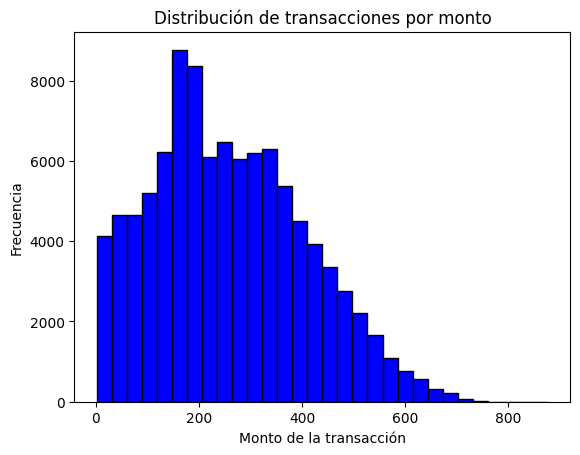

In [12]:
#Gráfico de distribución de las transacciones por monto - Variable numérica 
df_trans["amount"].plot.hist(bins=30, color="blue", edgecolor="black") 
plt.title("Distribución de transacciones por monto")
plt.xlabel("Monto de la transacción")
plt.ylabel("Frecuencia")


Text(0, 0.5, 'Frecuencia')

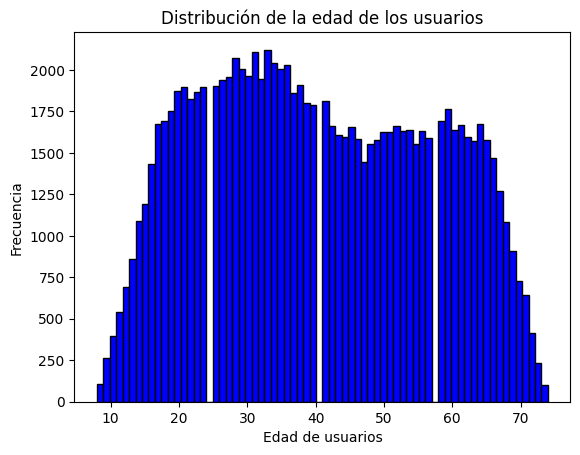

In [13]:
#Gráfico de distribución de edad de usuarios - Variable numérica 
df_trans["age_trans"].plot.hist(bins=70, color="blue", edgecolor="black")
plt.title("Distribución de la edad de los usuarios")
plt.xlabel("Edad de usuarios")
plt.ylabel("Frecuencia")

##### <font color="royalblue">**Gráfico de 2 variables numéricas**</font>

- Importar el módulo **seaborn** para generar gráficos y renombrarlo con el alias **sns**.
- Crear con el método **.displot()** de seaborn para distribuciones, un gráfico de contornos (densidad). Los argumentos usados son:
    - *x* valor en eje x *"amount"*,
    - *y* valor en eje y *"age_trans"*,
    - *data* dataframe *df_trans*,
    - *kind* tipo de gráfico a aplicar *"kde"*. 
- Dar contexto al gráfico usando las funciones:
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y. 

El gráfico de contornos es ideal para visualizar concentraciones de datos cuando hay muchos puntos, suavizando la distribución en dos dimensiones. Es interesante ver como se aprecia 2 sectores bien definidos con mayor densidad de puntos, relacionados a montos entre 150-200 $ y a los grupos de edades de usuarios descrito anterior de 18-40 años y 49-65 años. 


In [ ]:
#Gráfico de distribución de monto de transacciones y edad de usuarios - 2 Variable numérica 
sns.displot(x="amount", y="age_trans", data=df_trans, kind="kde", fill=True, cmap='Blues', edgecolor="black")
plt.title("Distribución conjunta de monto de transacción y edad de los usuarios")
plt.xlabel("Monto de la transacción")
plt.ylabel("Edad de los usuarios")

##### <font color="royalblue">**Gráfico de 1 variable categórica**</font>

- Crear con la función **.countplot()** de seaborn, 2 gráficos de distribución de la variable *"country_company"*. Los argumentos usados son:
    - *y* como país de las empresas *"country_company"*, 
    - *data* en un gráfico el dataframe *df_prod* para contar el número de empresas y en el otro gráfico *df_trans* para contar numero de transacciones.
- Dar contexto a cada gráfico usando las funciones:
    - **.figure()** para definir el tamaño 2D de ambos gráficos con el argumento *figsize*,
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y.
- Distribuir ambos gráficos con la función **.subplot()** y los argumentos *(filas, columnas, indice)*.
- Ajustar automaticamente los espacios con la función **.tight_layout()**.

El countplot permite a traves de un gráfico de barras visualizar la frecuencia dentro de una variable, es como un histograma para variables categóricas. En este caso se muestra:
- Gráfico 1: número de empresas por país.
- Grafico 2: número de transacciones asociadas a paises donde se localizan las empresas que venden en el e-commerce.  

En los gráficos podemos inferir que paises tienen menos o más empresas como el caso de China y España, y también cuantos representan el mayor o menor número de trasacciones realizadas. Se pueden establecer comparaciones como Alemania y Bélgica tienen el mismo numero de empresas (8), sin embargo al revisar el número de transacciones que realizan las empresas alemanas hace 3 veces más transacciones en el e-commerce que las empresas belgas.


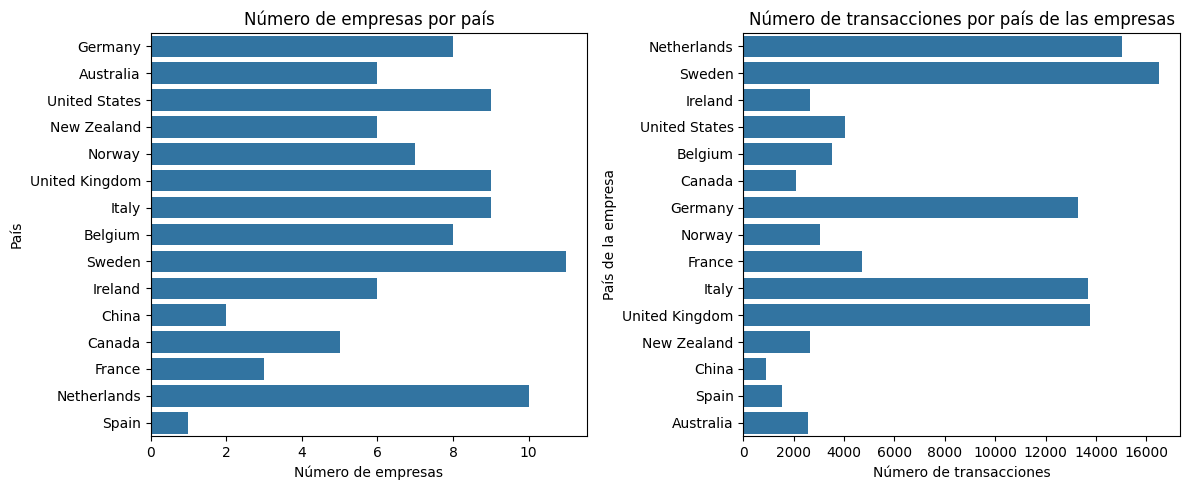

In [ ]:
#Gráficos de distribución de empresas por pais - Variable categórica 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(y="country", data=df["company"])          # gráfico de frecuencia respecto a cantidad de empresas
plt.title("Número de empresas por país")
plt.xlabel("Número de empresas")
plt.ylabel("País")
plt.subplot(1, 2, 2)
sns.countplot(y="country_company", data=df_trans)       # gráfico de frecuencia respecto a cantidad de transacciones
plt.title("Número de transacciones por país de las empresas")
plt.xlabel("Número de transacciones")
plt.ylabel("País de la empresa")
plt.tight_layout()


##### <font color="royalblue">**Gráfico de 1 variable categórica y 1 variable numérica**</font>

- Crear con la función **.boxplot()** de seaborn un gráfico de distribucion de 2 variables. Los argumentos usados son:
    - *x* valor en eje x *"age_trans"*,
    - *y* valor en eje y *"country_user"*,
    - *data* dataframe *df_trans*.
- Dar contexto al gráfico usando las funciones:
    - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y.

El gráfico de caja permite resumir la distribución de datos numéricos a través de cinco estadísticos: mínimo, primer cuartil Q1 (25%), mediana, tercer cuartil Q3 (75%) y máximo. Permite visualizar la dispersión, la simetría y detectar valores atípicos (outliers), siendo ideal para comparar distribuciones entre grupos categóricos. En este caso permite ver como varian las edades promedio de los usuarios en función del país; siendo más bajas para Cánada, Estados Unidos y Reino Unido en relación al resto de paises.


Text(0, 0.5, 'País')

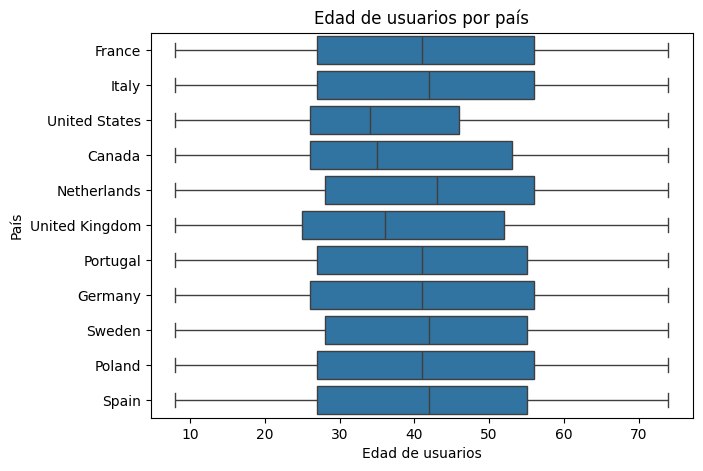

In [ ]:
#Gráfico de distribución de edad de usuarios por pais de origen - Variables numérica y categórica
plt.figure(figsize=(7, 5))
sns.boxplot(x="age_trans", y="country_user", data=df_trans)
plt.title("Edad de usuarios por país")
plt.xlabel("Edad de usuarios")
plt.ylabel("País")


 Crear con la función **.violinplot()** de seaborn un gráfico de distribucion de 2 variables. Los argumentos usados son:
   - *x* valor en eje x *"country_company"*,
   - *y* valor en eje y *"amount"*,
   - *data* dataframe *df_trans*,
- Dar contexto al gráfico usando las funciones:
    - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y. 

El grafico de violin permite identificar la forma de distribución, moda y dispersión de los datos. Es una visualización más detallado que un 
gráfico de caja, es muy útil cuando la forma de la distribución es importante, y no solo los datos de cuartiles.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Netherlands'),
  Text(1, 0, 'Sweden'),
  Text(2, 0, 'Ireland'),
  Text(3, 0, 'United States'),
  Text(4, 0, 'Belgium'),
  Text(5, 0, 'Canada'),
  Text(6, 0, 'Germany'),
  Text(7, 0, 'Norway'),
  Text(8, 0, 'France'),
  Text(9, 0, 'Italy'),
  Text(10, 0, 'United Kingdom'),
  Text(11, 0, 'New Zealand'),
  Text(12, 0, 'China'),
  Text(13, 0, 'Spain'),
  Text(14, 0, 'Australia')])

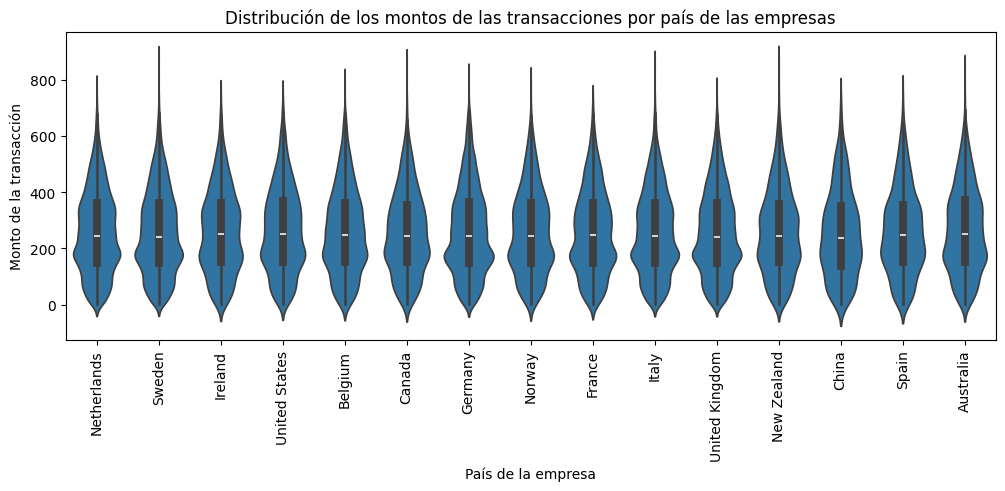

In [ ]:
#Gráfico de distribución de monto de transacciones por pais de empresas - Variables categórica y numérica
plt.figure(figsize=(12,4))
sns.violinplot(data=df_trans, y="amount", x="country_company")
plt.title("Distribución de monto de transacciones por país de empresas")
plt.xlabel("País de empresas")
plt.ylabel("Monto de transacciones")
plt.xticks(rotation=90)

#### <font color="royalblue">**Gráfico de 2 variables categóricas**</font>

- Crear con la función **.countplot()** de seaborn un gráfico de distribucion de 2 variables. Los argumentos usados son:
    - *y* valor en eje y *"country_company"*,
    - *hue* tono o matiz para la variable *"country_user"*,  
    - *data* dataframe *df_trans*.
- Dar contexto al gráfico usando las funciones:
    - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y. 

El countplot permite a través de un gráfico de barras visualizar la frecuencia dentro de una variable, es como un histograma para variables categóricas. En este gráfico se visualiza en que paises se desarrollan la actividad del e-commerce tanto para empresas como para usuarios, he incluso se cuantifica el número de transacciones hechas, de manera de poder comparar la relación entre los paises en función de comprador-vendedor.

Text(0, 0.5, 'País de empresas')

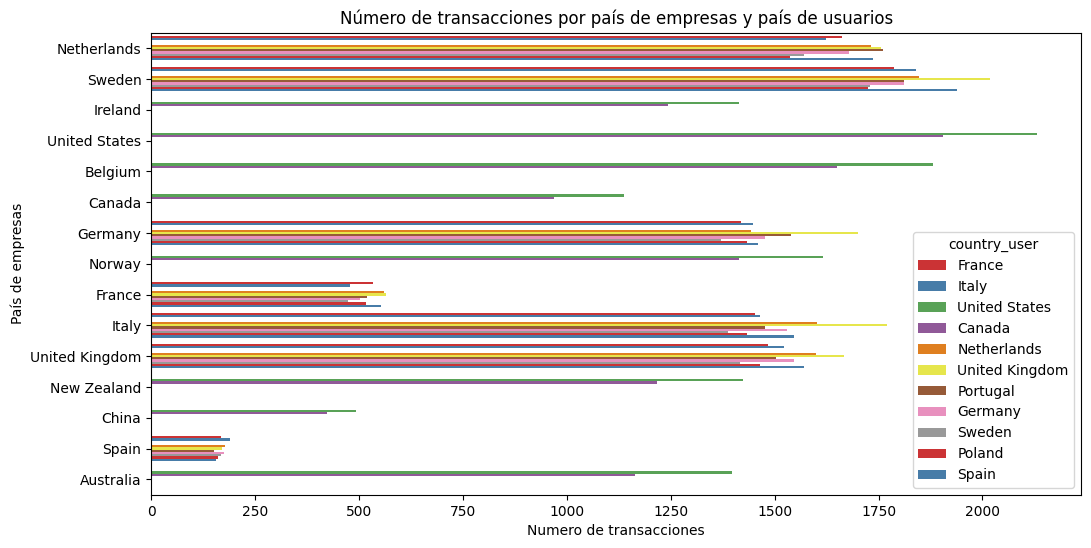

In [86]:
#Gráfico de distribución de edad de usuarios por pais de origen - 2 Variables categóricas 
plt.figure(figsize=(12,6))
sns.countplot(y="country_company",hue="country_user", data=df_trans, palette="Set1")
plt.title("Número de transacciones por país de empresas y país de usuarios")
plt.xlabel("Numero de transacciones")
plt.ylabel("País de empresas")

#### <font color="royalblue">**Gráfico de 3 variables**</font>

- Crear con la función **.boxplot()** de seaborn un gráfico de distribucion de 3 variables. Los argumentos usados son:
    - *x* valor en eje x *"country_company"*,
    - *y* valor en eje y *"amount"*,
    - *data* dataframe *df_trans*,
    - *hue* tono o matiz de la variable *"declined"*. 
- Dar contexto al gráfico usando las funciones:
    - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
    - **.title()** para poner título al gráfico, 
    - **.xlabel()** para título de eje x, 
    - **.ylabel()** para título de eje y,
    - **.xticks()** para inclinar la referencia al nombre de eje x unos 45º con el argumento *rotation*.

El gráfico de caja permite resumir la distribución de datos numéricos a través de cinco estadísticos: mínimo, primer cuartil Q1 (25%), mediana,
tercer cuartil Q3 (75%) y máximo. Permite visualizar la dispersión, la simetría y detectar valores atípicos (outliers), siendo ideal para 
comparar distribuciones entre grupos categóricos. En este caso permite ver para cada país como se distribuyen el monto de transacciones exitosas y las declinadas. De esta manera se identifica en que paises y en que magnitud afecta tanta las operaciones del e-commerce aprobadas y las rechazadas. Se observa en el gráfico que España tiene una cantidad muy pequeña de transacciones rechazadas, también se aprecia los valores atipicos que estan alejados de la estadística para cada país. 


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Netherlands'),
  Text(1, 0, 'Sweden'),
  Text(2, 0, 'Ireland'),
  Text(3, 0, 'United States'),
  Text(4, 0, 'Belgium'),
  Text(5, 0, 'Canada'),
  Text(6, 0, 'Germany'),
  Text(7, 0, 'Norway'),
  Text(8, 0, 'France'),
  Text(9, 0, 'Italy'),
  Text(10, 0, 'United Kingdom'),
  Text(11, 0, 'New Zealand'),
  Text(12, 0, 'China'),
  Text(13, 0, 'Spain'),
  Text(14, 0, 'Australia')])

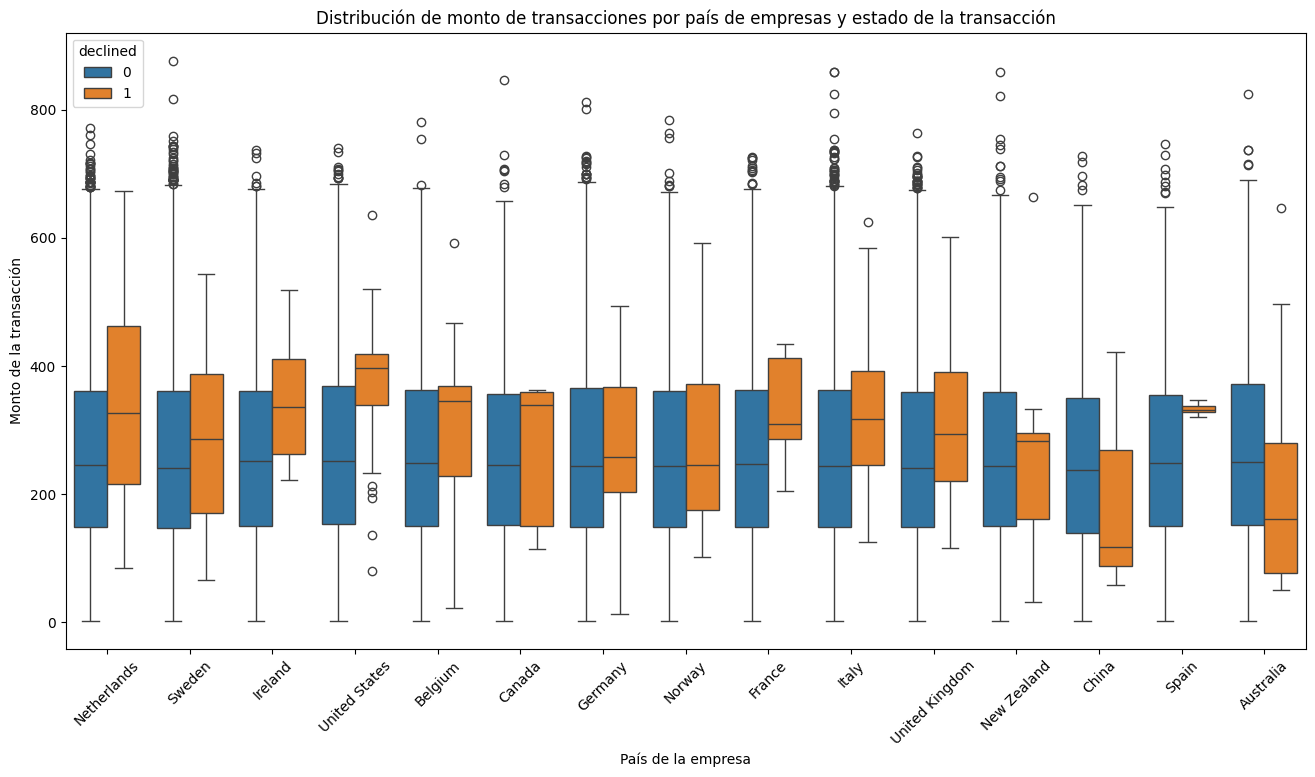

In [12]:
#Gráfico de distribución de monto de transacciones por pais de empresas y estado de la transacción - 3 Variables 
plt.figure(figsize=(16,8))
sns.boxplot(x="country_company", y="amount", data=df_trans, hue="declined")
plt.title("Distribución de monto de transacciones por país de empresas y estado de la transacción")
plt.xlabel("País de la empresa")
plt.ylabel("Monto de la transacción")
plt.xticks(rotation=45)

#### <font color="royalblue">**Gráfico Pairplot**</font>

- Crear con la función **.pairplot()** de seaborn un gráfico de distribucion de 3 variables numéricas. Los argumentos usados son:
   - el dataframe al inicio *df_prod*,
   - *vars* variables numéricas a correlacionar *"num_transaction"*, *"price"*, *"weight"*,
   - *kind* tipo de gráfica a utilizar para relación entre diferentes variables *"kde"*.
- Dar contexto usando las funciones **.suptitle()** para poner título principal al gráfico, se aplica argumento *y* para distanciar el titulo del área del gráfico.

El pairplot es ideal para análisis exploratorio, crea automáticamente una matriz de gráficos, mostrando las relaciones por pares entre todas las variables numéricas. Por la alta cantidad de puntos se cambio el tipo de gráfico entre variables a densidad, para enfocar el análisis en concentración de datos, de esta forma se observa la distribución de las variables al ser relacionadas.

Text(0.5, 1.02, 'Relación entre número de transacciones, precio y peso de productos')

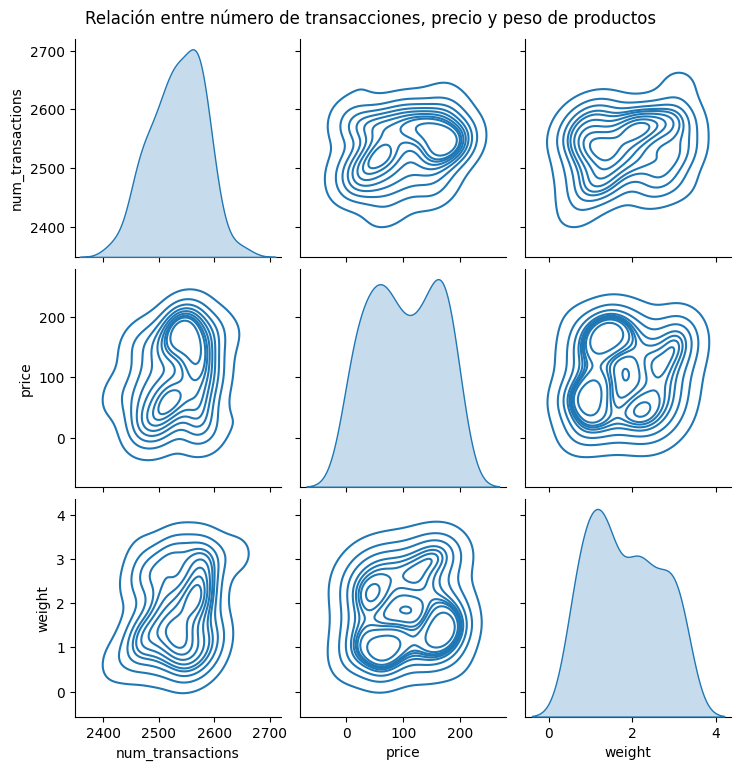

In [17]:
# Gráfico de relacion entre de precio de productos, numero de transacciones y peso - Variables numéricas
g = sns.pairplot(df_prod, vars=["num_transactions", "price","weight"], kind="kde" )
#g.set_axis_labels(["num transacciones", "precio", "peso"])
plt.suptitle("Relación entre número de transacciones, precio y peso de productos", y=1.02)

#### <font color="royalblue">**Nivel 2**</font>

#### <font color="royalblue"><u>Ejercicio 1</u></font>

Representa la correlación de algunas variables e interpreta los resultados según tus datos.


Diferencias entre tipos de correlacion (Pearson, Spearman, Kendall)

#### <font color="royalblue">**Gráfico Pairplot**</font>

- Calcular y guardar en variables las correlaciones con el método **.corr()**, pasando como argumento el tipo de correlación a aplicar:
   - *"pearson"* (por defecto): variable *corr_pears*
   - *"kendall"* (por defecto): variable *corr_kend*
   - *"spearman"* (por defecto): variable *corr_spear*
- Definir datos a correlacionar identificando el dataframe *df_trans* y los campos numéricos a considerar, en este caso *"amount", "num_products", "age_trans", "age"*.
- Crear con la función **.heatmap()** de seaborn 3 mapas de calor, una para cada correlación calculada. Los argumentos usados son:
   - el cálculo de correlación *corr_pears*, *corr_kend* y *corr_spear*.
   - *annot* para indicar si se desea ver en el mapa los valores de correlacion entre las variables,
   - *cmap* indica la paleta de colores a usar en el mapa de calor *"coolwarm"*.
- Dar contexto a la visualización usando las funciones: 
   - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
   - **.subplot()** para distribuir los 3 gráficos con los argumentos *filas, columnas, indice*,
   - **.title()** para poner título a cada gráfico individual,
   - **.suptitle()** para poner título principal al gráfico,
   - **.tight_layout()** ajusta automaticamente espacio evitando superposición. 

El mapa de calor crea una representación visual de datos en forma de matriz, los valores numéricos se codifican mediante colores. Es ideal para identificar rápidamente patrones, tendencias y correlaciones en conjuntos de datos complejos, visualizando la intensidad de los datos mediante una escala cromática. 

Los coeficientes de correlación describen la fuerza y ​​la dirección de una asociación entre variables. Pearson mide si hay o no una relación lineal. Spearman se enfoca en una definición más flexible de correlación debido a los rangos, se considera para grandes conjuntos de datos con pocos empates. Respecto a Kendall se considera cuando la muestra es pequeña y hay muchos empates.

Al ver el gráfico generado se observan valor similares entre los 3 mapas de calor para cada tipo de correlación, sin embargo retomando el comportamiento de los datos visualizados no se aprecia tendencia de relaciones lineales por lo que se descarta de primera Pearson. La base de datos *"marketplace"* presenta muchos valores de alta cardinalidad la posibilidad de empates es poca y las cantidad de valores es muy extensa por lo que se descarta Kendall y se toma Spearman en caso de requerir esta dato para futuros analisis.

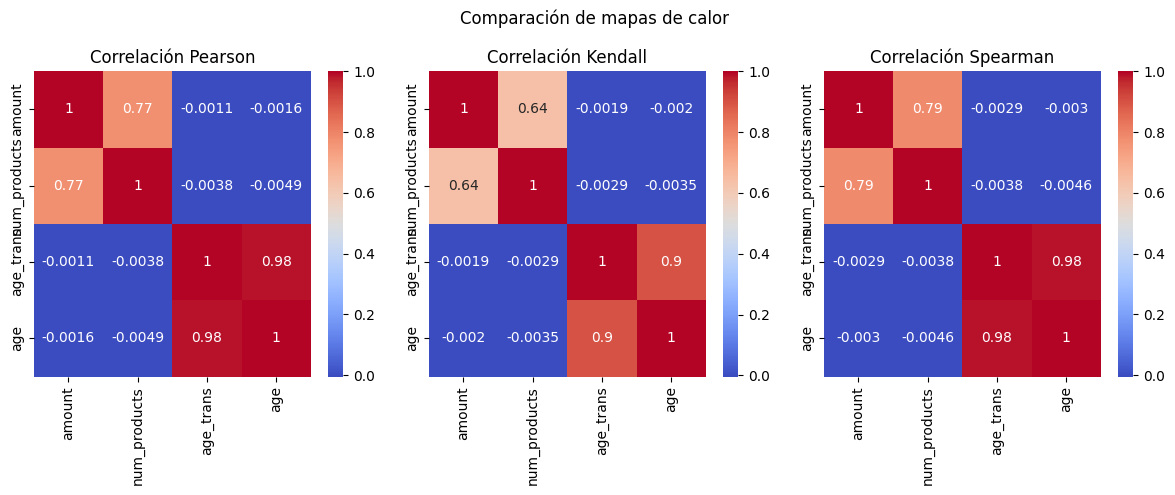

In [ ]:
# Gráficos de mapas de calor para comparar las correlaciones entre variables numéricas utilizando diferentes métodos
plt.figure(figsize=(12,5))
plt.subplot(1, 3, 1)
corr_pears = df_trans[["amount", "num_products", "age_trans", "age"]].corr()
sns.heatmap(corr_pears, annot=True, cmap="coolwarm")
plt.title("Correlación Pearson")
plt.subplot(1, 3, 2)
corr_kend = df_trans[["amount", "num_products", "age_trans", "age"]].corr("kendall")
sns.heatmap(corr_kend, annot=True, cmap='coolwarm')
plt.title("Correlación Kendall")
plt.subplot(1, 3, 3)
corr_spear = df_trans[["amount", "num_products", "age_trans", "age"]].corr("spearman")
sns.heatmap(corr_spear, annot=True, cmap='coolwarm')
plt.title("Correlación Spearman")
plt.suptitle("Comparación de mapas de calor")
plt.tight_layout()

#### <font color="royalblue"><u>Ejercicio 2</u></font>

Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.


#### <font color="royalblue">**Gráfico Jointplot**</font>

- Crear con la función **.jointplot()** de seaborn un gráfico de distribucion de 2 variables numéricas. Los argumentos usados son:
   - *x* valor en eje x *"age_trans"*,
   - *y* valor en eje y *"amount"*,
   - *data* dataframe *df_trans_num* creada a partir de las variables numéricas de *df_trans*, 
   - *kind* tipo de gráfica a utilizar para relación entre diferentes variables *"kde"*.
   - *cmap* paleta de colores *"Blues"*
   - *fill* relleno de color entre los contornos, 
- Dar contexto a la visualización usando las funciones: 
   - **.set_style()** de seaborn para establecer el estilo del gráfico *"whitegrid"*,
   - **.figure()** para definir el tamaño 2D del gráfico con el argumento *figsize*,
   - **.suptitle()** para poner título principal al gráfico, con argumento *y* se distancia el titulo del área del gráfico,
   - **.xlabel()** para titulo del eje x,
   - **.ylabel()** para titulo del eje y,
   - **.tight_layout()** ajusta automaticamente espacio evitando superposición. 

El jointplot permite visualizar la relación entre dos variables (distribución conjunta) junto con la distribución individual de cada una (distribuciones marginales) en un solo gráfico. Combina un gráfico central con gráficos de distribución en los ejes.   
En este caso se retoman la visualización de la edad de usuarios con el monto de transaccciones visto en las primeras gráficas, pero ahora se puede apreciar todo en conjunto. Como la tendencia o concentración de la distribución individual de ambas variables *amount* y *age_trans* se ven reflejadas en el gráfico de contorno que relaciona ambas variables, definiendo 2 sectores con gran densidad de datos.

c:\Python\Python312\Lib\site-packages\seaborn\distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  cset = contour_func(


Text(40.347222222222214, 0.5, 'Monto de transacciones')

<Figure size 1000x1000 with 0 Axes>

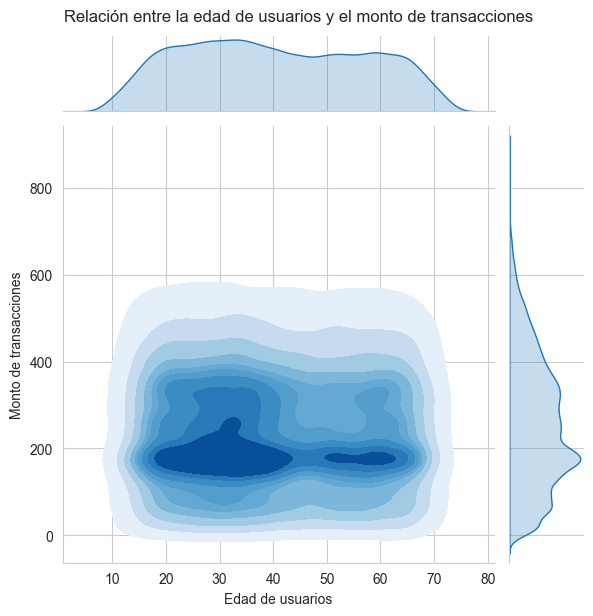

In [ ]:
# Gráfico de relación entre edad de usuarios y monto de transacciones utilizando un gráfico de densidad conjunta (KDE)

df_trans_num = df_trans[["amount", "num_products", "age_trans"]]  # df con variables numéricas para el gráfico de densidad conjunta

sns.set_style("whitegrid")
plt.figure(figsize=(10,10))
sns.jointplot( x="age_trans", y="amount", data=df_trans_num, kind="kde", cmap="Blues", fill=True)
plt.suptitle("Relación entre la edad de usuarios y el monto de transacciones", y=1.02)  
plt.xlabel("Edad de usuarios")
plt.ylabel("Monto de transacciones")


#### <font color="royalblue">**Nivel 3**</font>

#### <font color="royalblue"><u>Ejercicio 1</u></font>

Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: **cuando cargues tus dataframes en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. Por defecto, Power BI elimina duplicados y podrías perder información**.